# Mini Project
# **Assignment Submission Guidelines**


Please follow the guidelines below for submitting your assignment:

1. **Submission Deadline:**
   - All assignments must be submitted **no later than 11:59 PM Next Friday (07/10) Midnight**.
   - Late submissions will not be accepted unless prior arrangements have been made by the instructor.

2. **Submission Platform:**
   - Submit your assignment through **Canvas**. Ensure that you upload the files to the correct assignment link.

3. **Required Files:**
   - **Jupyter Notebook file (.ipynb):** Submit the Jupyter Notebook file you used to complete the assignment. The file should contain your well-commented code.
   - **PDF Version (.pdf file):** Additionally, submit a PDF version of your Python code. This can be a printout or export of your script, showing all the code with any necessary explanations or output results included.

4. **File Naming Convention:**
   - Please name your files as follows: `Lastname_Firstname_AssignmentName`
   - Example: `Alex_John_Mini_Project.ipynb` and `Alex_Johb_Mini_Project.pdf`

5. **Technical Issues:**
   - If you encounter any technical issues with Canvas or your submission, please contact the TAs immediately **before the deadline** to avoid penalties.

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it.

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16).
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [586]:
import random

class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def get_value(self):
        # face cards are worth 10. the ace starts as 11 here and gets adjusted later if needed
        if self.rank in ['J', 'Q', 'K']:
            return 10
        elif self.rank == 'A':
            return 11
        else:
            return self.rank

    def __repr__(self):
        return str(self.rank) + self.suit


class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.start_size = num_decks * 52
        self.reshuffle = False
        self.shuffle()

    def shuffle(self):
    # rebuild all the decks each time instead of only reshuffling the leftovers,
    # otherwise the deck eventually runs out in the middle of a game
        self.cards = []
        ranks = [2, 3, 4, 5, 6, 7, 8, 9, 10, 'J', 'Q', 'K', 'A']
        suits = ['H', 'D', 'S', 'C']
        for d in range(self.num_decks):
            for s in suits:
                for r in ranks:
                    self.cards.append(Card(r, s))
        random.shuffle(self.cards)
        #cut = int(self.start_size * 0.65)
        #self.cards.insert(cut, "PLASTIC") # Old logic just for testing

        # put the plastic card at a random location in the deck
        cut = random.randint(1, len(self.cards) - 1)
        self.cards.insert(cut, "PLASTIC")

        self.reshuffle = False

    def draw(self):
        if len(self.cards) == 0:
            self.shuffle()

        card = self.cards.pop(0)

        if card == "PLASTIC":
            self.reshuffle = True
            return self.draw()

        return card

    def needs_shuffle(self):
        return self.reshuffle

    def __len__(self):
        return len(self.cards)

deck = Deck(6)
print("cards in the deck:", len(deck))

# draw a few cards just to check the deck actually works
first_cards = list()
for i in range(5):
    first_cards.append(deck.draw())
print("first 5 off the top:", first_cards)


cards in the deck: 313
first 5 off the top: [5D, 5C, JS, 2S, KD]


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook.

In [587]:
# Class structuer:
# Player (parent)
#   -> Dealer (child)
#   -> HumanPlayer (child)
#   -> CardCountingPlayer (child)
#           -> MyStrategyPlayer (child of the counter)
#
# Ownership/composition:
# Game has a Deck and a list of Players
# Deck made of Cards
# Player has a Hand
# Hand made of Cards

# For this part, I just google UML maker and clicked on "smartdraw.com".
# As it turns out, you must purchase the software to export it as a PDF directly.
# So unfortunately I had to just take a screenshot of the work and then save that as a PDF.

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [588]:
class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        pass

    def get_value(self):
        pass

    def is_bust(self):
        pass


class Player:
    def __init__(self, name, chips=100):
        self.name = name
        self.chips = chips
        self.hand = Hand()
        self.bet = 0

    def reset_hand(self):
        pass

    def place_bet(self, amount):
        pass

    def decide(self, dealer_card, seen):
        pass


class Dealer(Player):
    def decide(self, dealer_card=None, seen=None):
        pass


class HumanPlayer(Player):
    def decide(self, dealer_card, seen):
        pass


class Game:
    def __init__(self, players, num_decks=6, verbose=True):
        self.players = players
        self.dealer = None
        self.deck = None
        self.verbose = verbose
        self.seen = []

    def deal_one(self, hand):
        pass

    def play_round(self):
        pass

    def play(self, n_rounds):
        pass


4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [589]:
class Hand:
    def __init__(self):
        self.cards = list()

    def add_card(self, card):
        self.cards.append(card)

    def get_value(self):
        hand_value = 0
        ace_count = 0

        for card in self.cards:
            hand_value = hand_value + card.get_value()

            if card.rank == 'A':
                ace_count = ace_count + 1

        # start every ace at 11 and drop it to 1 one at a time while the hand is over 21
        while hand_value > 21 and ace_count > 0:
            hand_value = hand_value - 10
            ace_count = ace_count - 1

        return hand_value

    def is_bust(self):
        if self.get_value() > 21:
            return True
        else:
            return False


class Player:
    def __init__(self, name, chips=100):
        self.name = name
        self.chips = chips
        self.hand = Hand()
        self.bet = 0

    def reset_hand(self):
        self.hand = Hand()
        self.bet = 0

    def place_bet(self, amount):
        bet_amount = amount

        if bet_amount > self.chips:
            bet_amount = self.chips

        self.bet = bet_amount
        self.chips = self.chips - bet_amount

        return bet_amount

    def decide(self, dealer_card, seen):
        return 'stay'


class Dealer(Player):
    def decide(self, dealer_card=None, seen=None):
        if self.hand.get_value() < 17:
            return 'hit'
        else:
            return 'stay'


class HumanPlayer(Player):
    def decide(self, dealer_card, seen):
        print('Your cards:', self.hand.cards)
        print('Your hand value:', self.hand.get_value())
        print('The dealer is showing:', dealer_card)

        player_choice = input('Take another card or stay? (h/s): ')
        player_choice = player_choice.lower()

        if player_choice.startswith('h'):
            return 'hit'
        else:
            return 'stay'


class Game:
    def __init__(self, players, num_decks=6, verbose=True):
        self.players = players
        self.dealer = Dealer('Dealer', chips=0)
        self.deck = Deck(num_decks)
        self.verbose = verbose
        self.seen = list()

    def log(self, message):
        if self.verbose:
            print(message)

    def deal_one(self, hand):
        drawn_card = self.deck.draw()
        hand.add_card(drawn_card)
        self.seen.append(drawn_card)
        return drawn_card

    def play_round(self):
        if self.deck.needs_shuffle() == True:
            self.log('The plastic card was reached. Shuffling the deck.')
            self.deck.shuffle()
            self.seen = list()

        active_players = list()

        # players with no chips left do not get a hand this round
        for player in self.players:
            player.reset_hand()

            if player.chips > 0:
                player.place_bet(10)
                active_players.append(player)

        self.dealer.reset_hand()

        # deal two cards to each player and a single visible card to the dealer
        for player in active_players:
            self.deal_one(player.hand)
            self.deal_one(player.hand)

        dealer_card = self.deal_one(self.dealer.hand)
        self.log('Dealer is showing: ' + str(dealer_card))

        # each player finishes their whole turn before the next player goes
        for player in active_players:
            player_done = False

            while player_done == False:
                if player.hand.is_bust() == True:
                    player_done = True
                else:
                    player_move = player.decide(dealer_card, self.seen)

                    if player_move == 'hit':
                        self.deal_one(player.hand)
                        self.log(player.name + ' takes a card and now has ' + str(player.hand.get_value()))
                    else:
                        player_done = True

            if player.hand.is_bust() == True:
                self.log(player.name + ' went over 21.')

        # dealer draws until reaching at least 17
        dealer_done = False

        while dealer_done == False:
            if self.dealer.decide() == 'hit':
                self.deal_one(self.dealer.hand)
                self.log('Dealer takes a card and now has ' + str(self.dealer.hand.get_value()))
            else:
                dealer_done = True

        dealer_value = self.dealer.hand.get_value()
        self.log('Dealer finished with ' + str(dealer_value))

        # compare each player to the final dealer hand and pay out the winners
        for player in active_players:
            player_value = player.hand.get_value()

            if player.hand.is_bust() == True:
                self.log(player.name + ' lost because the hand was over 21.')

            elif self.dealer.hand.is_bust() == True:
                player.chips = player.chips + (player.bet * 2)
                self.log(player.name + ' won because the dealer went over 21.')

            elif player_value > dealer_value:
                player.chips = player.chips + (player.bet * 2)
                self.log(player.name + ' won ' + str(player_value) + ' to ' + str(dealer_value))

            elif player_value == dealer_value:
                player.chips = player.chips + player.bet
                self.log(player.name + ' tied the dealer.')

            else:
                self.log(player.name + ' lost ' + str(player_value) + ' to ' + str(dealer_value))

    def play(self, n_rounds):
        for round_number in range(n_rounds):
            self.log('===== Round ' + str(round_number + 1) + ' =====')
            self.play_round()


# Checking the ace logic before using it in a full game.
test_hand = Hand()
test_hand.add_card(Card('A', 'H'))
test_hand.add_card(Card('K', 'S'))

print('A + K =', test_hand.get_value())


A + K = 21


5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [590]:
class BasicPlayer(Player):
    def decide(self, dealer_card, seen):
        if self.hand.get_value() < 17:
            return "hit"
        else:
            return "stay"


table = [BasicPlayer("Jayden", 200), BasicPlayer("Brayden", 200), BasicPlayer("Okayden", 200)]
game = Game(table, num_decks=6, verbose=True)
game.play(4)

print()
for player in table:
    print(player.name, "ended with", player.chips, "chips")


===== Round 1 =====
Dealer is showing: QC
Brayden takes a card and now has 13
Brayden takes a card and now has 22
Brayden went over 21.
Okayden takes a card and now has 17
Dealer takes a card and now has 16
Dealer takes a card and now has 18
Dealer finished with 18
Jayden won 20 to 18
Brayden lost because the hand was over 21.
Okayden lost 17 to 18
===== Round 2 =====
Dealer is showing: JS
Jayden takes a card and now has 17
Okayden takes a card and now has 16
Okayden takes a card and now has 13
Okayden takes a card and now has 17
Dealer takes a card and now has 20
Dealer finished with 20
Jayden lost 17 to 20
Brayden tied the dealer.
Okayden lost 17 to 20
===== Round 3 =====
The plastic card was reached. Shuffling the deck.
Dealer is showing: 10S
Jayden takes a card and now has 22
Jayden went over 21.
Brayden takes a card and now has 23
Brayden went over 21.
Dealer takes a card and now has 15
Dealer takes a card and now has 24
Dealer finished with 24
Jayden lost because the hand was ove

6. Implement a new player with the following strategy:

    * Assign each card a value:
        * Cards 2 to 6 are +1
        * Cards 7 to 9 are 0
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [591]:
class CardCountingPlayer(Player):
    def __init__(self, name, chips=100, threshold=0):
        super().__init__(name, chips)
        self.threshold = threshold
        self.count = 0

    def card_count_value(self, card):
        # low cards count as +1, middle cards as 0, high cards as -1
        if card.rank in [2, 3, 4, 5, 6]:
            return 1
        elif card.rank in [7, 8, 9]:
            return 0
        else:
            return -1

    def decide(self, dealer_card, seen):
        """Looks at every card seen so far, adds up the count, and returns
        'hit' or 'stay' based on the hand and that count."""
        self.count = 0
        for card in seen:
            self.count = self.count + self.card_count_value(card)

        hand_value = self.hand.get_value()

        # always take a card on a low hand, always stop on a high one
        if hand_value >= 17:
            return "stay"
        if hand_value <= 11:
            return "hit"

        # in between, let the count decide: lots of high cards left means stop, otherwise hit
        if self.count > self.threshold:
            return "stay"
        else:
            return "hit"


7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [592]:
starting_chips = 500

counter = CardCountingPlayer("Counter", starting_chips, threshold=0)

other_players = list()
for i in range(3):
    player_name = "Basic" + str(i + 1)
    other_players.append(BasicPlayer(player_name, starting_chips))

game = Game([counter] + other_players, verbose=False)

# play up to 50 rounds, but stop early if the counter runs out of chips
for round_number in range(50):
    if counter.chips <= 0:
        break
    game.play_round()

winnings = counter.chips - starting_chips
print("counter started with", starting_chips, "and ended with", counter.chips)
print("winnings after 50 rounds:", winnings)


counter started with 500 and ended with 410
winnings after 50 rounds: -90


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


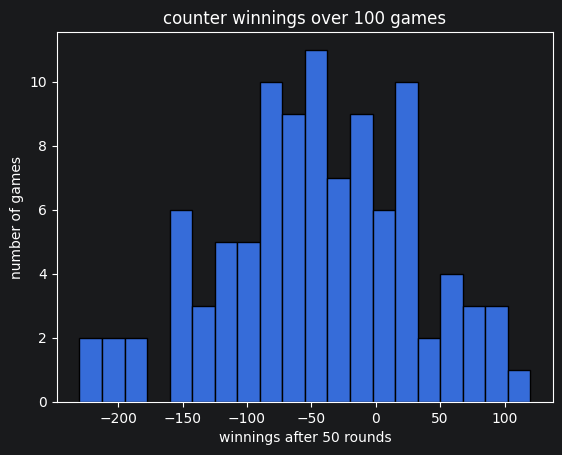

average winnings per round: -0.946
standard deviation: 74.84457228149547
chance of winning: 0.26
chance of losing: 0.71


In [593]:
import numpy as np
import matplotlib.pyplot as plt


def run_one_game(threshold=0, rounds=50, start=500):
    """Plays one full game with a counting player and 3 basic players, and
    returns how many chips the counter finished up or down."""
    counter = CardCountingPlayer("Counter", start, threshold=threshold)

    all_players = [counter]
    for i in range(3):
        player_name = "Basic" + str(i + 1)
        all_players.append(BasicPlayer(player_name, start))

    game = Game(all_players, verbose=False)
    game.play(rounds)

    return counter.chips - start


# play 100 separate games and record what the counter walked away with each time
winnings = list()
for game_number in range(100):
    winnings.append(run_one_game())

plt.hist(winnings, bins=20, edgecolor="black")
plt.xlabel("winnings after 50 rounds")
plt.ylabel("number of games")
plt.title("counter winnings over 100 games")
plt.show()

# count how many games ended up ahead vs behind, then turn those into chances
games_won = 0
games_lost = 0
for result in winnings:
    if result > 0:
        games_won = games_won + 1
    elif result < 0:
        games_lost = games_lost + 1

print("average winnings per round:", np.mean(winnings) / 50)
print("standard deviation:", np.std(winnings))
print("chance of winning:", games_won / 100)
print("chance of losing:", games_lost / 100)


9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

threshold -4 -> average winnings -48.1
threshold -2 -> average winnings -44.9
threshold 0 -> average winnings -55.3
threshold 2 -> average winnings -35.2
threshold 4 -> average winnings -47.6


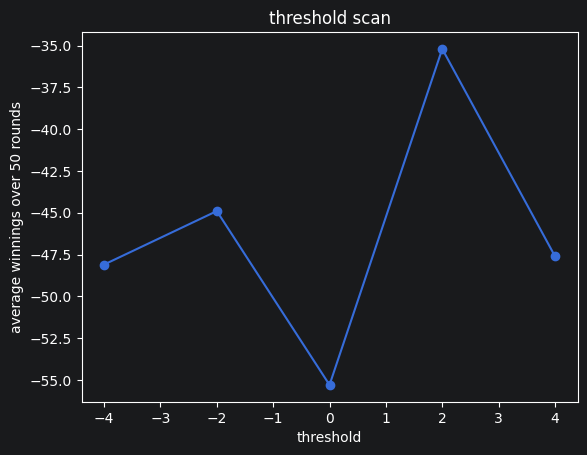

best threshold looks like 2 with average -35.2


In [594]:
thresholds = [-4, -2, 0, 2, 4]
average_results = list()

for threshold in thresholds:
    winnings = list()
    for game_number in range(100):
        winnings.append(run_one_game(threshold=threshold))

    average_winnings = np.mean(winnings)
    average_results.append(average_winnings)
    print("threshold", threshold, "-> average winnings", round(average_winnings, 1))

plt.plot(thresholds, average_results, marker="o")
plt.xlabel("threshold")
plt.ylabel("average winnings over 50 rounds")
plt.title("threshold scan")
plt.show()

# walk through the results and keep whichever threshold had the best average
best_threshold = thresholds[0]
best_average = average_results[0]
for i in range(len(thresholds)):
    if average_results[i] > best_average:
        best_average = average_results[i]
        best_threshold = thresholds[i]

print("best threshold looks like", best_threshold, "with average", round(best_average, 1))


10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings.

plain counter -> average -23.6
my strat -> average -40.8
difference -> -17.2 (positive means my strategy did better)


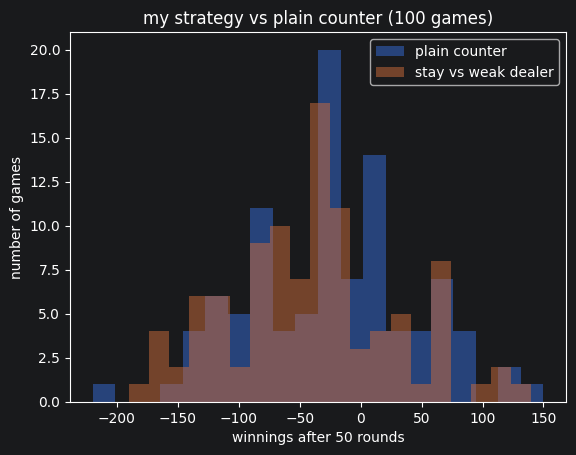

In [595]:
class MyStrategyPlayer(CardCountingPlayer):
    def decide(self, dealer_card, seen):
        hand_value = self.hand.get_value()

        # if the dealer is showing a weak card (2-6) it often goes over 21, so
        # stop on anything 12 or higher and let the dealer take the risk
        if dealer_card.rank in [2, 3, 4, 5, 6]:
            if hand_value >= 12:
                return "stay"

        # otherwise fall back to the normal counting strategy
        return super().decide(dealer_card, seen)


def run_my_strategy(rounds=50, start=500):
    """Plays one full game with my strategy player and 3 basic players, and
    returns how many chips my player finished up or down."""
    strategy_player = MyStrategyPlayer("Me", start, threshold=0)

    all_players = [strategy_player]
    for i in range(3):
        player_name = "Basic" + str(i + 1)
        all_players.append(BasicPlayer(player_name, start))

    game = Game(all_players, verbose=False)
    game.play(rounds)

    return strategy_player.chips - start


# compare my strategy against the plain counter over 100 games
plain_counter_winnings = list()
my_strategy_winnings = list()

for game_number in range(100):
    plain_counter_winnings.append(run_one_game(threshold=0))
    my_strategy_winnings.append(run_my_strategy())

plain_avg = np.mean(plain_counter_winnings)
mine_avg = np.mean(my_strategy_winnings)

print("plain counter -> average", round(plain_avg, 1))
print("my strat -> average", round(mine_avg, 1))
print("difference ->", round(mine_avg - plain_avg, 1),
      "(positive means my strategy did better)")

plt.hist(plain_counter_winnings, bins=20, alpha=0.5, label="plain counter")
plt.hist(my_strategy_winnings, bins=20, alpha=0.5, label="stay vs weak dealer")
plt.xlabel("winnings after 50 rounds")
plt.ylabel("number of games")
plt.title("my strategy vs plain counter (100 games)")
plt.legend()
plt.show()